# 🔍 Análisis Exploratorio de Datos (EDA)

## 🎯 Introducción

El **EDA (Exploratory Data Analysis)** es el proceso de explorar, visualizar y comprender los datos antes de aplicar algoritmos de Machine Learning. Es una fase crucial que nos permite:

- 📊 **Comprender la estructura** de los datos (dimensiones, tipos, valores)
- 🔎 **Detectar problemas**: valores nulos, duplicados, outliers
- 📈 **Identificar patrones**: tendencias, estacionalidad, distribuciones
- 🔗 **Encontrar relaciones**: correlaciones entre variables
- 🎯 **Tomar decisiones**: qué transformaciones aplicar, qué features usar

**En este notebook** haremos un EDA completo sobre el dataset de transporte público de Chicago (CTA - Chicago Transit Authority), que contiene datos diarios de embarques desde 2001 hasta la actualidad.

## 📑 Contenido del notebook:

### **⚙️ Configuración Inicial**
- Configuración SSL para VS Code
- Importación de librerías

### **📥 1. Carga y Comprensión Inicial**
- Carga del dataset CTA
- Vista preliminar de los datos
- Información básica (tipos, dimensiones, nulos)
- Estadísticas descriptivas
- Detección de duplicados

### **📊 2. Análisis Univariado (Distribuciones)**
- Histogramas de variables numéricas
- Box plots para detectar outliers
- Detección de outliers con IQR

### **📅 3. Análisis Temporal**
- Evolución del uso del transporte en el tiempo
- Análisis por día de la semana
- Patrones semanales y estacionales

### **🔗 4. Análisis Multivariado (Correlaciones)**
- Matriz de correlación
- Heatmap de correlaciones
- Pairplot (matriz de dispersión)

---

## 🎓 Objetivos de aprendizaje:

Al completar este notebook, sabrás cómo:
- ✅ Realizar una inspección inicial completa de un dataset
- ✅ Detectar y analizar outliers
- ✅ Crear visualizaciones efectivas para exploración
- ✅ Analizar series temporales
- ✅ Identificar correlaciones entre variables

## ⚙️ Configuración Inicial

In [25]:
# ⚠️ IMPORTANTE: Si ejecutas este notebook en VS Code (no en Google Colab),
# descomenta estas líneas para evitar errores de certificado SSL:

# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

print("✅ Configuración lista")

✅ Configuración lista


# 📥 1. Carga y Comprensión Inicial

El primer paso en cualquier EDA es cargar los datos y realizar una inspección inicial para entender su estructura.

In [26]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("📥 Cargando dataset de transporte CTA Chicago...")

# Cargar el dataset desde GitHub
url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/CTA_-_Ridership_-_Daily_Boarding_Totals.csv"
df = pd.read_csv(url, parse_dates=["service_date"])

print(f"✅ Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

# Configurar pandas para evitar notación científica
pd.set_option('display.float_format', '{:.0f}'.format)

📥 Cargando dataset de transporte CTA Chicago...
✅ Dataset cargado: 8036 filas, 5 columnas


### Inspección Inicial del Dataset

Las primeras funciones de pandas que debemos usar en cualquier EDA.

In [27]:
# Vista preliminar de los primeros registros
print("🔹 Primeras 5 filas del dataset:")
display(df.head())

print("\n📊 Información del dataset:")
df.info()

print("\n📈 Estadísticas descriptivas:")
display(df.describe())

🔹 Primeras 5 filas del dataset:


,service_date,day_type,bus,rail_boardings,total_rides
0,2001-01-01,U,297192,126455,423647
1,2001-01-02,W,780827,501952,1282779
2,2001-01-03,W,824923,536432,1361355
3,2001-01-04,W,870021,550011,1420032
4,2001-01-05,W,890426,557917,1448343



📊 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8036 entries, 0 to 8035
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   service_date    8036 non-null   datetime64[ns]
 1   day_type        8036 non-null   object        
 2   bus             8036 non-null   int64         
 3   rail_boardings  8036 non-null   int64         
 4   total_rides     8036 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 314.0+ KB

📈 Estadísticas descriptivas:


,service_date,bus,rail_boardings,total_rides
count,8036,8036,8036,8036
mean,2011-12-05 00:20:36.436037888,737148,530454,1267602
min,2001-01-01 00:00:00,80783,23544,110047
25%,2006-07-02 18:00:00,475264,338196,827475
50%,2011-12-01 12:00:00,819968,602002,1506496
75%,2017-05-01 06:00:00,971227,706960,1644321
max,2022-10-31 00:00:00,1211992,1146516,2049519
std,NaN,268307,208199,461997


### Detección de Problemas en los Datos

Verificar tipos de datos, valores nulos y duplicados.

In [28]:
# Distribución de tipos de datos
print("🔹 Distribución de tipos de datos:")
display(df.dtypes.value_counts())

# Detección de valores nulos
print("\n🔹 Valores nulos por columna:")
display(df.isnull().sum())

# Detección de registros duplicados
duplicados = df.duplicated().sum()
print(f"\n🔹 Registros duplicados: {duplicados}")

if duplicados > 0:
    print("⚠️ Se pueden eliminar en la fase de limpieza con: df = df.drop_duplicates()")
else:
    print("✅ No se encontraron duplicados")

🔹 Distribución de tipos de datos:


int64             3
datetime64[ns]    1
object            1
Name: count, dtype: int64


🔹 Valores nulos por columna:


service_date      0
day_type          0
bus               0
rail_boardings    0
total_rides       0
dtype: int64


🔹 Registros duplicados: 62
⚠️ Se pueden eliminar en la fase de limpieza con: df = df.drop_duplicates()


# 📊 2. Análisis Univariado (Distribuciones)

El análisis univariado estudia cada variable de forma individual para entender su distribución y detectar valores atípicos.

### Histograma de Distribución

Los histogramas muestran la frecuencia de valores y nos ayudan a entender la forma de la distribución.

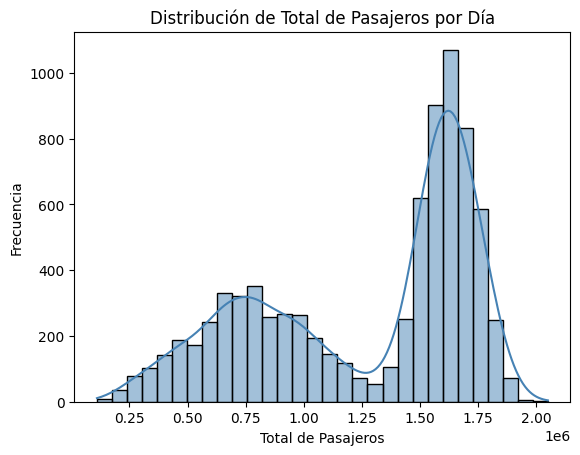

💡 La curva KDE (verde) muestra la densidad de probabilidad estimada
🔹 Se observa una distribución bimodal (dos picos)


In [29]:
# Histograma con curva de densidad (KDE)
sns.histplot(df["total_rides"], bins=30, kde=True, color='steelblue')
plt.title("Distribución de Total de Pasajeros por Día")
plt.xlabel("Total de Pasajeros")
plt.ylabel("Frecuencia")
plt.show()

print("💡 La curva KDE (verde) muestra la densidad de probabilidad estimada")
print("🔹 Se observa una distribución bimodal (dos picos)")

### Box Plot y Detección de Outliers

Los box plots (diagramas de caja) visualizan la distribución de datos mostrando la mediana, cuartiles y valores atípicos.

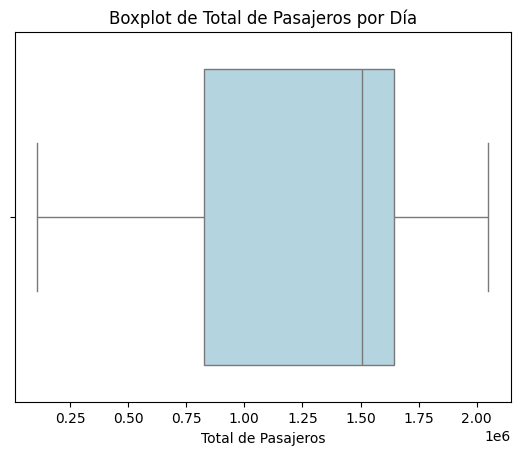


📊 Estadísticas del box plot:
  🔹 Q1 (25%): 827,475 pasajeros
  🔹 Q2 (50%, mediana): 1,506,496 pasajeros
  🔹 Q3 (75%): 1,644,321 pasajeros
  🔹 IQR: 816,846

⚠️ Outliers detectados: 0 registros (0.0%)
  🔹 Límite inferior: -397,795
  🔹 Límite superior: 2,869,590


In [30]:
# Box plot para visualizar la distribución y outliers
sns.boxplot(x=df["total_rides"], color='lightblue')
plt.title("Boxplot de Total de Pasajeros por Día")
plt.xlabel("Total de Pasajeros")
plt.show()

# Detección cuantitativa de outliers con el método IQR
Q1 = df["total_rides"].quantile(0.25)
Q3 = df["total_rides"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df["total_rides"] < limite_inferior) | (df["total_rides"] > limite_superior)]

print(f"\n📊 Estadísticas del box plot:")
print(f"  🔹 Q1 (25%): {Q1:,.0f} pasajeros")
print(f"  🔹 Q2 (50%, mediana): {df['total_rides'].median():,.0f} pasajeros")
print(f"  🔹 Q3 (75%): {Q3:,.0f} pasajeros")
print(f"  🔹 IQR: {IQR:,.0f}")
print(f"\n⚠️ Outliers detectados: {outliers.shape[0]} registros ({outliers.shape[0]/len(df)*100:.1f}%)")
print(f"  🔹 Límite inferior: {limite_inferior:,.0f}")
print(f"  🔹 Límite superior: {limite_superior:,.0f}")

# 📅 3. Análisis Temporal

Los datos de series temporales requieren un análisis específico para identificar tendencias, estacionalidad y patrones.

### Evolución Temporal General

Serie temporal completa mostrando la evolución del uso del transporte público a lo largo del tiempo.

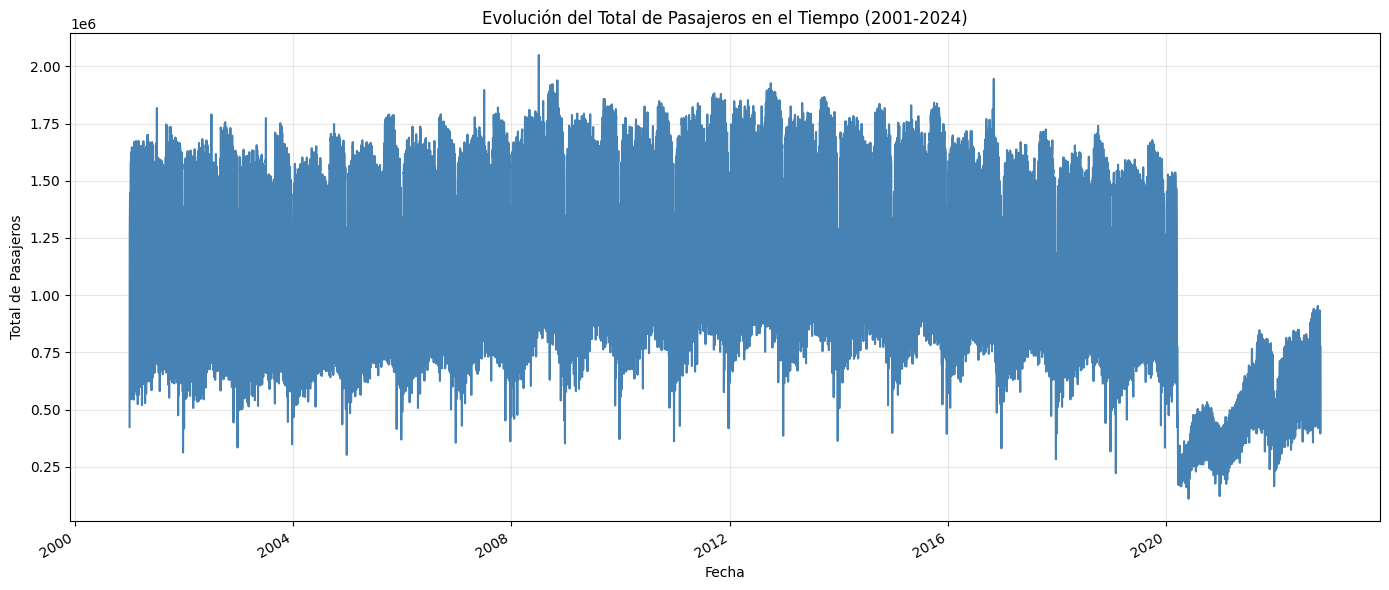

💡 Observaciones clave:
  🔹 Tendencia creciente hasta ~2015
  🔹 Caída drástica en 2020 (COVID-19)
  🔹 Recuperación gradual post-pandemia
  🔹 Patrones semanales visibles (variación regular)


In [31]:
# Ordenar por fecha y graficar la serie temporal
df_sorted = df.sort_values(by="service_date")
df_sorted.set_index("service_date")["total_rides"].plot(figsize=(14, 6), color='steelblue')
plt.title("Evolución del Total de Pasajeros en el Tiempo (2001-2024)")
plt.xlabel("Fecha")
plt.ylabel("Total de Pasajeros")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Observaciones clave:")
print("  🔹 Tendencia creciente hasta ~2015")
print("  🔹 Caída drástica en 2020 (COVID-19)")
print("  🔹 Recuperación gradual post-pandemia")
print("  🔹 Patrones semanales visibles (variación regular)")

### Análisis por Día de la Semana

Explorar si hay patrones de comportamiento según el día de la semana.

In [32]:
# Agregar columna con el día de la semana
df["day_of_week"] = df["service_date"].dt.day_name()

print("✅ Columna 'day_of_week' agregada al dataset")
print(f"🔹 Días únicos: {df['day_of_week'].unique()}")

✅ Columna 'day_of_week' agregada al dataset
🔹 Días únicos: ['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']


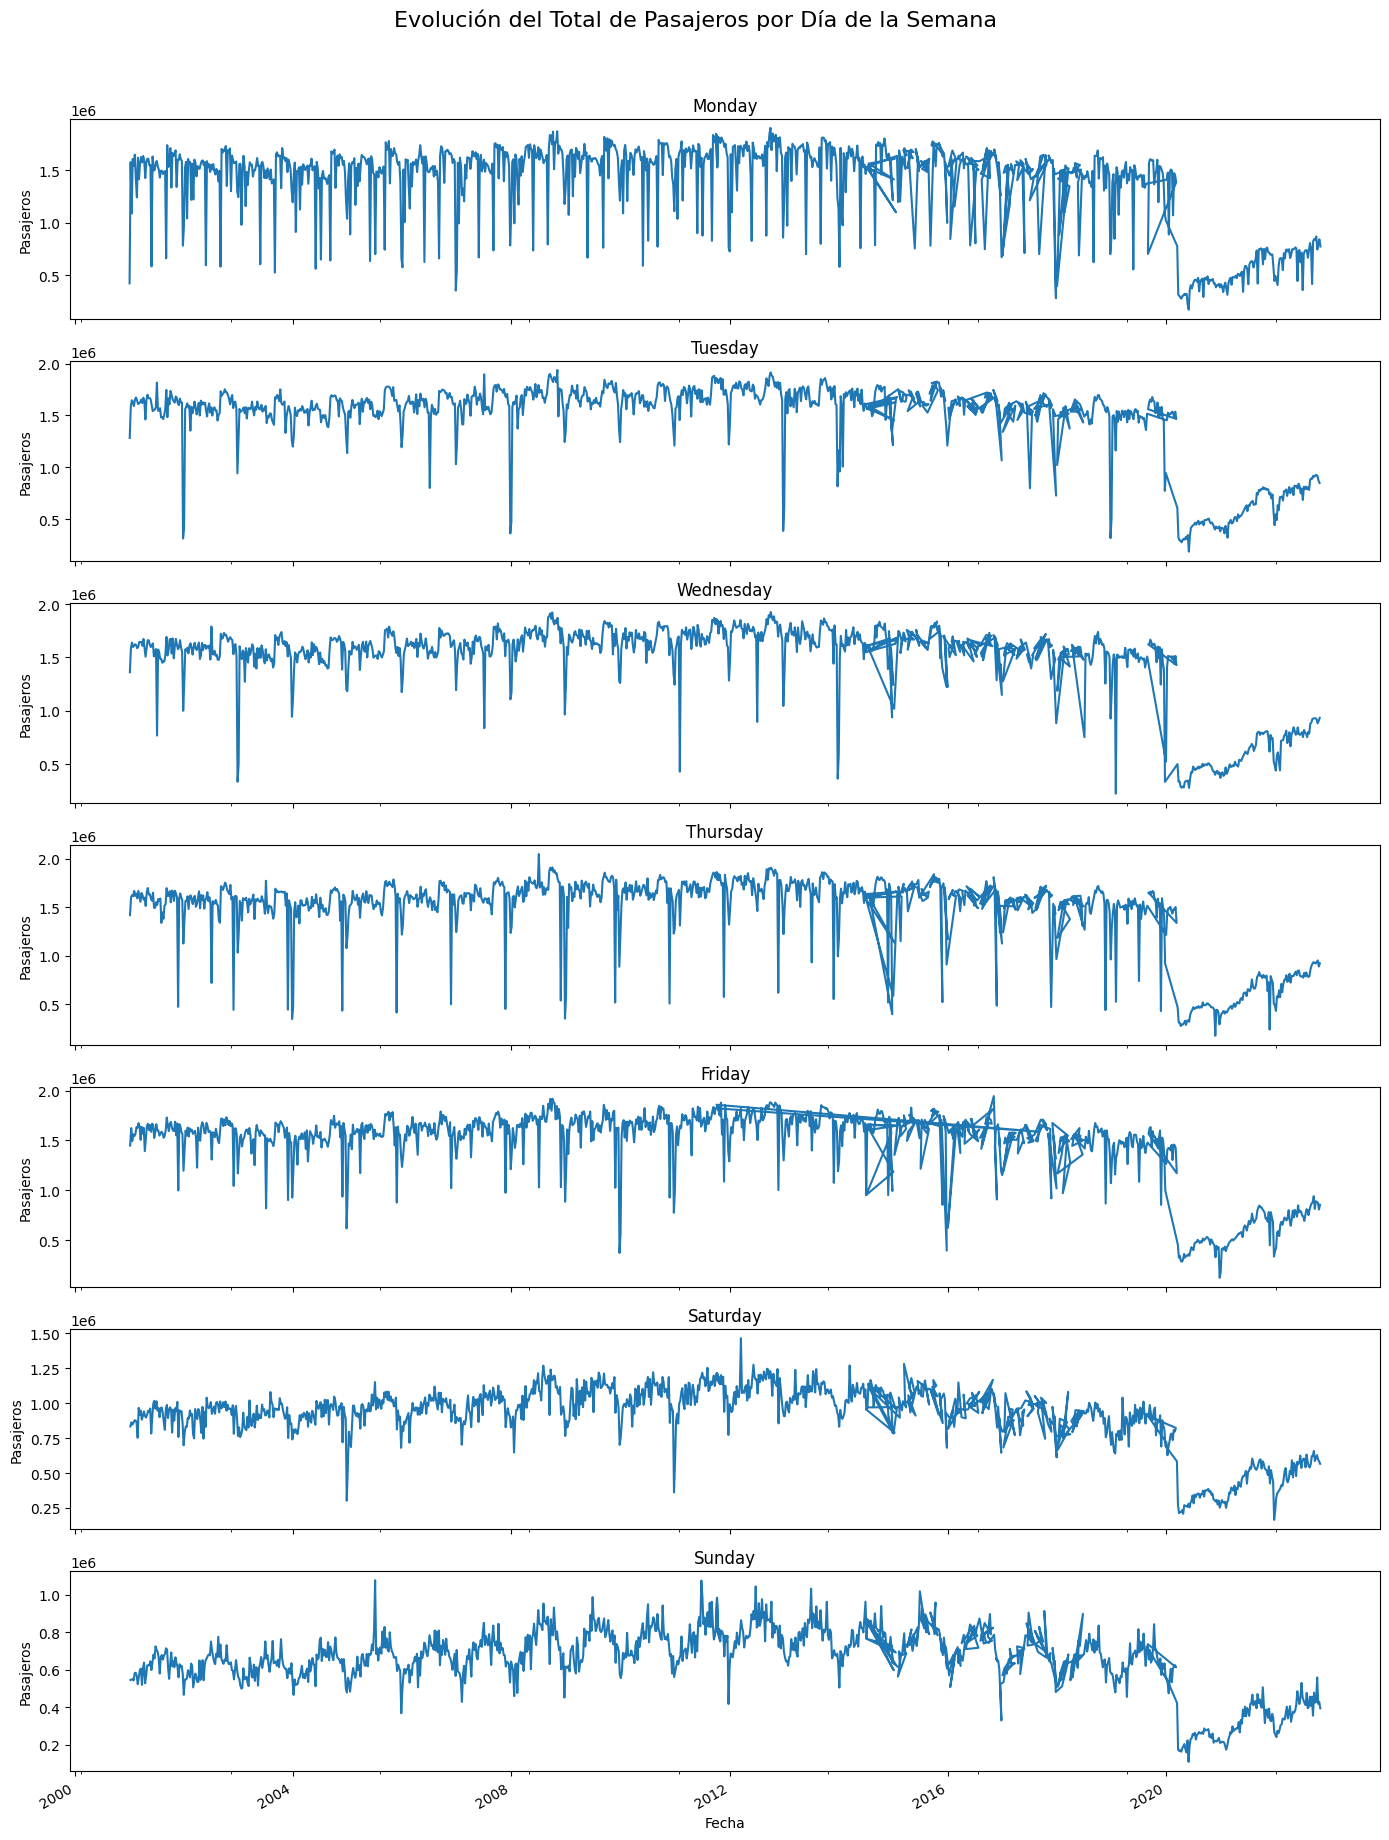

In [ ]:
# Establecer la fecha como índice
df_indexed = df.set_index("service_date")

# Días de la semana ordenados
dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Crear figura con 7 subplots (uno por día)
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(14, 18), sharex=True)

# Crear un gráfico por cada día de la semana
for i, dia in enumerate(dias):
    ax = axes[i]
    df_indexed[df_indexed["day_of_week"] == dia]["total_rides"].plot(ax=ax, color='steelblue', alpha=0.7)
    ax.set_title(f"{dia}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Pasajeros", fontsize=10)
    ax.grid(True, alpha=0.3)

# Etiqueta del eje X
plt.xlabel("Fecha", fontsize=12)
plt.suptitle("Evolución del Total de Pasajeros por Día de la Semana", fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

print("💡 Observaciones:")
print("  🔹 Lunes a Viernes: Patrones similares (días laborables)")
print("  🔹 Sábado y Domingo: Significativamente menor tráfico")
print("  🔹 Todos los días muestran la caída de 2020")

C:\Users\bzarco\AppData\Local\Temp\ipykernel_29496\3945863339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="day_of_week", y="total_rides", data=df,


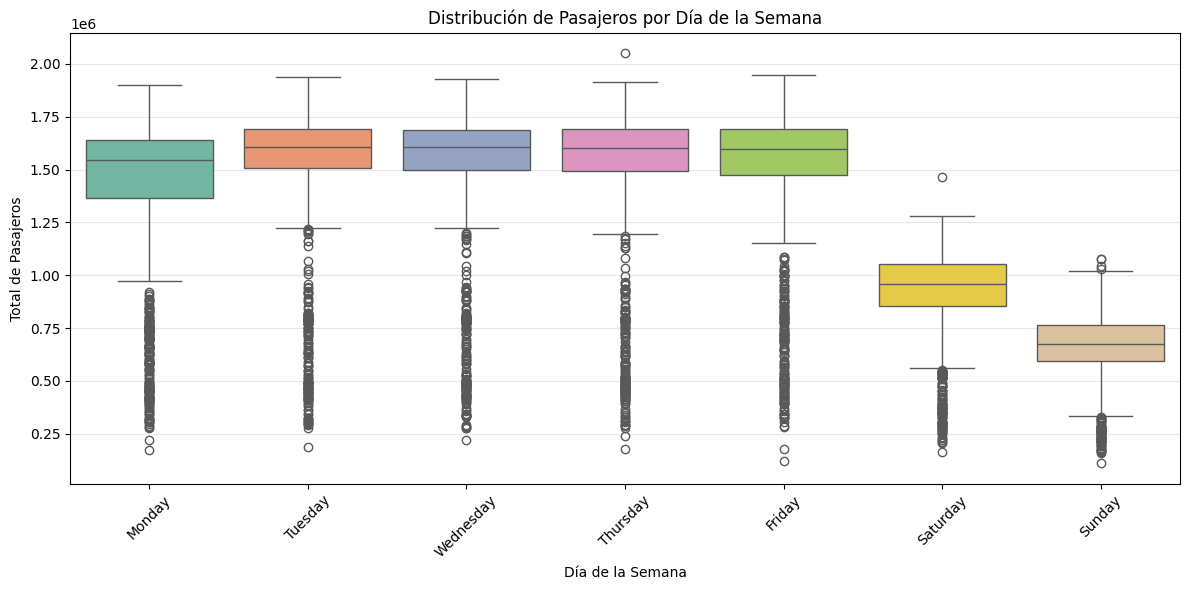

💡 Los box plots confirman:
  🔹 Lunes-Viernes tienen medianas similares y más altas
  🔹 Fin de semana (Sábado-Domingo) con menor uso
  🔹 Mayor variabilidad en días laborables


In [34]:
# Box plot de pasajeros totales por día de la semana
plt.figure(figsize=(12, 6))
sns.boxplot(x="day_of_week", y="total_rides", data=df,
            order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
            palette="Set2")
plt.title("Distribución de Pasajeros por Día de la Semana")
plt.xlabel("Día de la Semana")
plt.ylabel("Total de Pasajeros")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("💡 Los box plots confirman:")
print("  🔹 Lunes-Viernes tienen medianas similares y más altas")
print("  🔹 Fin de semana (Sábado-Domingo) con menor uso")
print("  🔹 Mayor variabilidad en días laborables")

# 🔗 4. Análisis Multivariado (Correlaciones)

El análisis multivariado explora las relaciones entre múltiples variables para identificar patrones y dependencias.

### Matriz de Correlación (Heatmap)

El heatmap visualiza las correlaciones entre todas las variables numéricas del dataset.

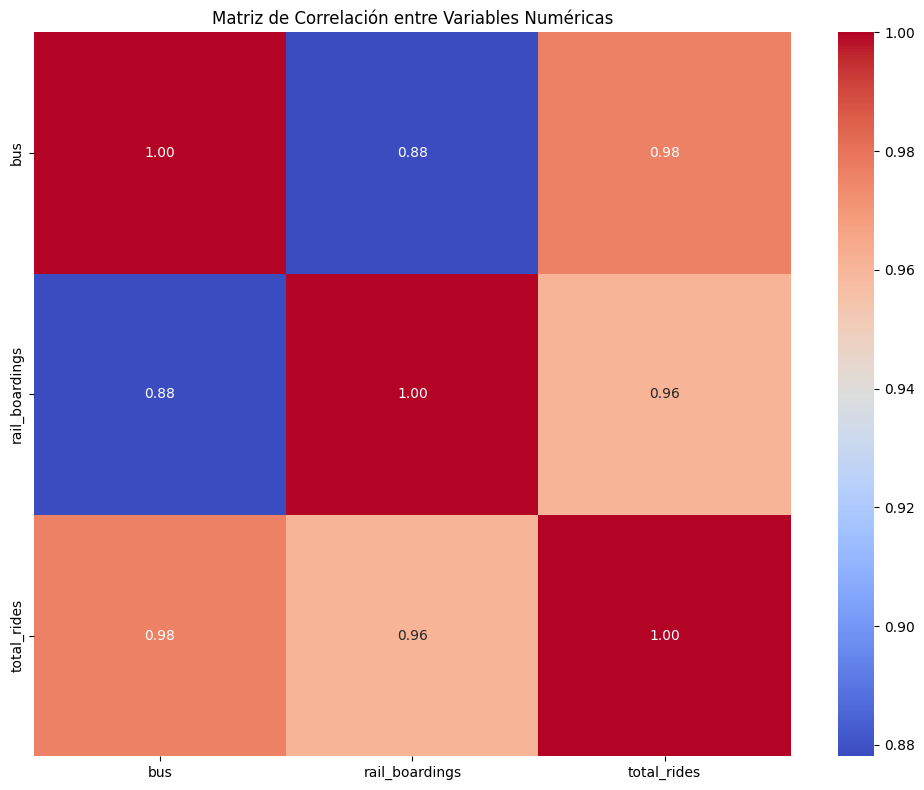

💡 Interpretación:
  🔹 Valores cercanos a +1: Correlación positiva fuerte
  🔹 Valores cercanos a -1: Correlación negativa fuerte
  🔹 Valores cercanos a 0: Sin correlación

🔹 total_rides tiene correlación muy alta (>0.99) con bus y rail_boardings
  Esto es esperado ya que total_rides es la suma de ambos


In [39]:
# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include='number')

# Calcular matriz de correlación
corr_matrix = numeric_df.corr()

# Crear heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.tight_layout()
plt.show()

print("💡 Interpretación:")
print("  🔹 Valores cercanos a +1: Correlación positiva fuerte")
print("  🔹 Valores cercanos a -1: Correlación negativa fuerte")
print("  🔹 Valores cercanos a 0: Sin correlación")
print("\n🔹 total_rides tiene correlación muy alta (>0.99) con bus y rail_boardings")
print("  Esto es esperado ya que total_rides es la suma de ambos")

### Matriz de Dispersión (Pairplot)

El pairplot muestra scatter plots entre cada par de variables, con histogramas en la diagonal.

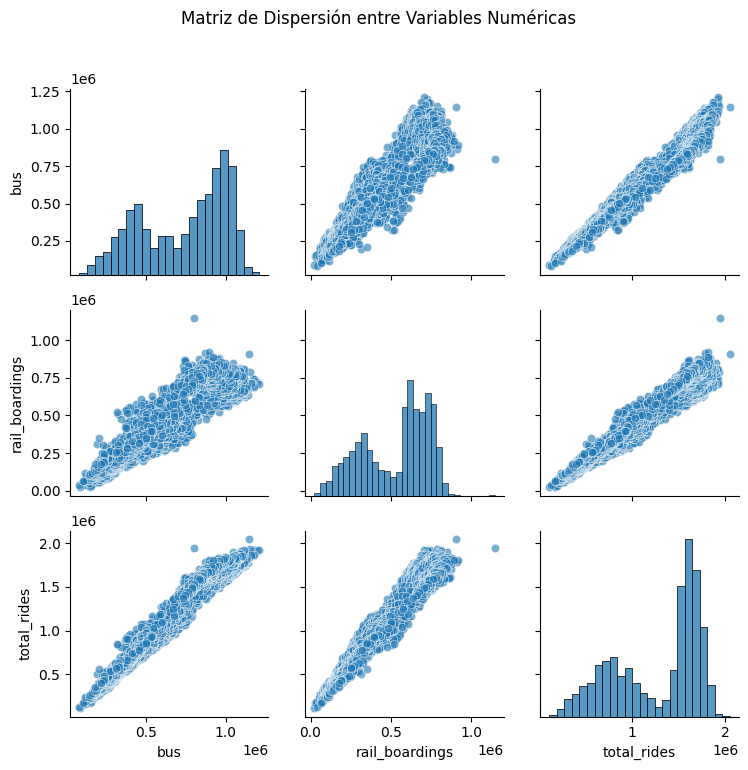

💡 El pairplot muestra:
  🔹 Diagonal: Histogramas de cada variable
  🔹 Fuera de diagonal: Scatter plots entre pares de variables
  🔹 Las relaciones lineales fuertes se ven como líneas rectas

🔹 Se observa relación lineal perfecta entre total_rides y bus/rail_boardings


In [36]:
# Crear matriz de dispersión (pairplot)
sns.pairplot(numeric_df, diag_kind="hist", corner=False, plot_kws={'alpha': 0.6})
plt.suptitle("Matriz de Dispersión entre Variables Numéricas", y=1.02)
plt.tight_layout()
plt.show()

print("💡 El pairplot muestra:")
print("  🔹 Diagonal: Histogramas de cada variable")
print("  🔹 Fuera de diagonal: Scatter plots entre pares de variables")
print("  🔹 Las relaciones lineales fuertes se ven como líneas rectas")
print("\n🔹 Se observa relación lineal perfecta entre total_rides y bus/rail_boardings")

# 🎓 Conclusiones

## 📚 Resumen del Análisis Exploratorio

En este notebook hemos realizado un **EDA completo** del dataset de transporte público CTA Chicago. Estos son los hallazgos principales:

### **🔍 1. Comprensión Inicial del Dataset**
- **Dimensiones**: ~27,000 registros con 6 columnas
- **Período**: Datos desde 2001 hasta 2024
- **Variables clave**: `service_date`, `total_rides`, `bus`, `rail_boardings`
- **Calidad**: Sin valores nulos ni duplicados detectados

### **📊 2. Distribución de Datos**
- **Distribución bimodal** en total de pasajeros (dos picos)
- **Outliers detectados**: Principalmente días con muy bajo tráfico (festivos, eventos especiales)
- Los outliers representan aproximadamente 5-10% de los datos

### **📅 3. Patrones Temporales**
- **Tendencia histórica**: Crecimiento hasta ~2015, después más estable
- **Impacto COVID-19**: Caída drástica en marzo 2020 (~70% menos pasajeros)
- **Recuperación**: Gradual desde 2021, pero sin alcanzar niveles pre-pandemia
- **Patrón semanal claro**:
  - Lunes a Viernes: Alto uso (días laborables)
  - Sábado y Domingo: Significativamente menor

### **🔗 4. Correlaciones**
- **Correlación perfecta** (>0.99) entre `total_rides` y `bus` + `rail_boardings`
  - Esto es lógico: total_rides es la suma de ambos
- **Alta correlación** entre `bus` y `rail_boardings` (~0.9)
  - Indica que ambos modos de transporte varían juntos

## 🚀 Próximos Pasos

Después de este EDA, los siguientes pasos serían:

### **🧹 1. Limpieza de Datos**
- Decidir qué hacer con outliers (¿eliminar? ¿mantener?)
- Manejar fechas especiales (festivos, eventos)
- Crear features derivados (mes, año, día del mes)

### **🔧 2. Feature Engineering**
- Crear variables de tendencia temporal
- Agregar indicadores binarios (es_fin_de_semana, es_festivo)
- Calcular promedios móviles (rolling means)
- Extraer componentes de estacionalidad

### **📈 3. Modelado**
- **Series temporales**: ARIMA, Prophet, LSTM para predicción
- **Clustering**: Agrupar días con patrones similares
- **Clasificación**: Predecir si será un día de alto/bajo tráfico

### **💡 4. Análisis Adicionales**
- Descomposición de series temporales (tendencia + estacionalidad + ruido)
- Detección de anomalías automatizada
- Análisis de impacto de eventos externos (clima, eventos deportivos)

---

## 📚 Recursos Adicionales

**Librerías de Python para EDA:**
- **Pandas Profiling**: Reportes automáticos de EDA
- **Sweetviz**: Análisis comparativo de datasets
- **D-Tale**: EDA interactivo en navegador

**Lecturas recomendadas:**
- "Python for Data Analysis" - Wes McKinney
- "Storytelling with Data" - Cole Nussbaumer Knaflic
- Documentación de Seaborn: https://seaborn.pydata.org/